# Logistic Regression — Heart Disease Prediction

In this module, we will build a Logistic Regression model using a real-world
heart disease dataset from Kaggle.

We will:

1. Download the dataset using the Kaggle API
2. Explore and clean the data
3. Perform Exploratory Data Analysis
4. Prepare features and target
5. Split the data into training and testing sets
6. Train a Logistic Regression model
7. Generate probability predictions
8. Convert probabilities into classes
9. Evaluate the model
10. Visualize the results
11. Test the model on new data

### Prediction Problem

We want to predict whether a patient has a 10-year risk of coronary heart disease.

Target:

TenYearCHD

0 → No 10-year CHD risk

1 → 10-year CHD risk

#Install Kaggle

In [15]:
!pip install -q kaggle

#Import Libraries

In [16]:
import os
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Kaggle API Authentication

We will use `getpass()` to enter the Kaggle API token securely.

The token will not be displayed while entering it.

In [17]:
from getpass import getpass
import os

kaggle_token = getpass("Enter your Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

del kaggle_token

print("Kaggle API token configured successfully.")

Enter your Kaggle API token: ··········
Kaggle API token configured successfully.


## Download the Dataset

Kaggle Dataset:

`dileep070/heart-disease-prediction-using-logistic-regression`

We will download and extract the dataset directly into Google Colab.

In [18]:
!mkdir -p /content/heart_disease_dataset

!kaggle datasets download \
    -d dileep070/heart-disease-prediction-using-logistic-regression \
    -p /content/heart_disease_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression
License(s): unknown
100% 58.4k/58.4k [00:00<00:00, 33.2MB/s]



#Check Downloaded Files

In [19]:
os.listdir("/content/heart_disease_dataset")

['framingham.csv']

#Find CSV Files Automatically

In [20]:
csv_files = [
    file
    for file in os.listdir("/content/heart_disease_dataset")
    if file.lower().endswith(".csv")
]

csv_files

['framingham.csv']

#Load the Dataset

In [21]:
dataset_path = os.path.join(
    "/content/heart_disease_dataset",
    csv_files[0]
)

df = pd.read_csv(dataset_path)

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


#Dataset Shape

In [22]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4238
Columns: 16


#Column Names

In [23]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
male
age
education
currentSmoker
cigsPerDay
BPMeds
prevalentStroke
prevalentHyp
diabetes
totChol
sysBP
diaBP
BMI
heartRate
glucose
TenYearCHD


#Dataset Information

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


#Statistical Summary

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.429212,0.495022,0.00,0.00,0.0,1.000,1.0
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
education,4133.0,1.978950,1.019791,1.00,1.00,2.0,3.000,4.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentStroke,4238.0,0.005899,0.076587,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0


#Check Missing Values

## Missing Values

Before training the model, we need to identify missing values.

We will inspect the number of missing values in every column.

In [26]:
missing_values = df.isnull().sum()

missing_values = (
    missing_values
    .sort_values(ascending=False)
)

missing_values

,0
glucose,388
education,105
BPMeds,53
totChol,50
cigsPerDay,29
BMI,19
heartRate,1
male,0
prevalentHyp,0
prevalentStroke,0


#Missing Value Percentage

In [27]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

,0
glucose,9.155262
education,2.477584
BPMeds,1.250590
totChol,1.179802
cigsPerDay,0.684285
BMI,0.448325
heartRate,0.023596
male,0.000000
prevalentHyp,0.000000
prevalentStroke,0.000000


#Visualize Missing Values

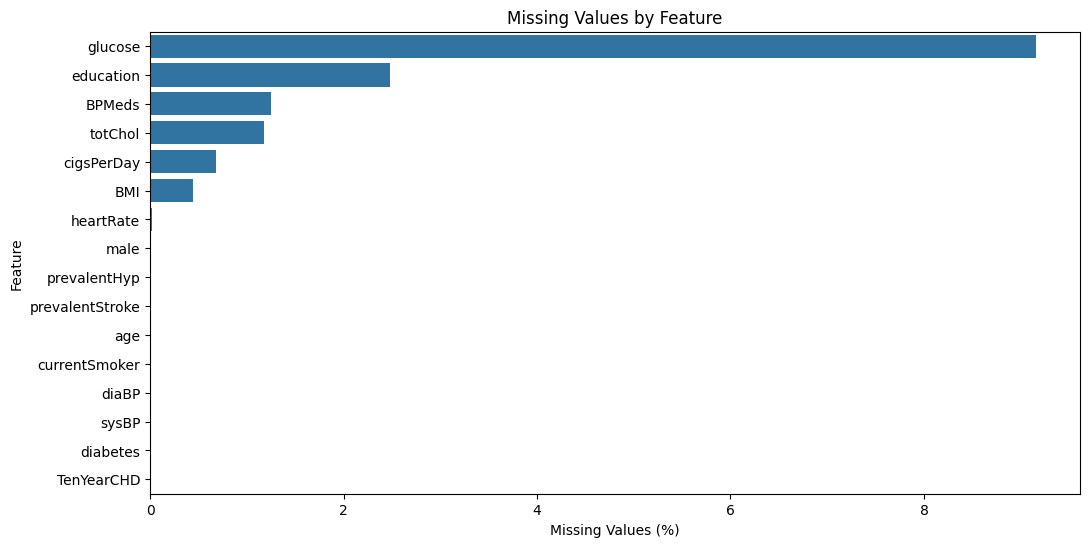

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.show()

#Check Duplicate Rows

In [29]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


## Target Variable

Our target variable is:

`TenYearCHD`

It represents whether the patient has a 10-year risk of coronary heart disease.

This is a **binary classification problem**:

0 → No

1 → Yes

In [30]:
print(df["TenYearCHD"].value_counts())

TenYearCHD
0    3594
1     644
Name: count, dtype: int64


#. Target Distribution

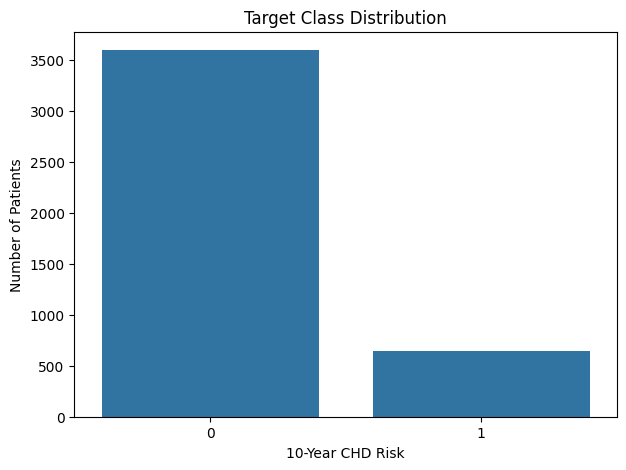

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="TenYearCHD"
)

plt.xlabel("10-Year CHD Risk")
plt.ylabel("Number of Patients")
plt.title("Target Class Distribution")

plt.show()

#Target Percentage

In [32]:
target_percentage = (
    df["TenYearCHD"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

print(target_percentage)

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


#Check Target Balance

## Class Distribution

The target classes are not necessarily equally represented.

This is important because a model can achieve high accuracy by favoring
the majority class while performing poorly on the minority class.

Therefore, later we will evaluate the model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC

For a medical-risk classification problem, recall/sensitivity is particularly
important to examine because false negatives can be consequential.

#Quick Data Preview

In [33]:
display(df.head(10))

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


#Identify Numeric Columns

In [34]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


#Correlation Matrix

## Feature Correlation

Correlation helps us understand linear relationships between numerical
variables.

We will visualize the correlations before selecting features.

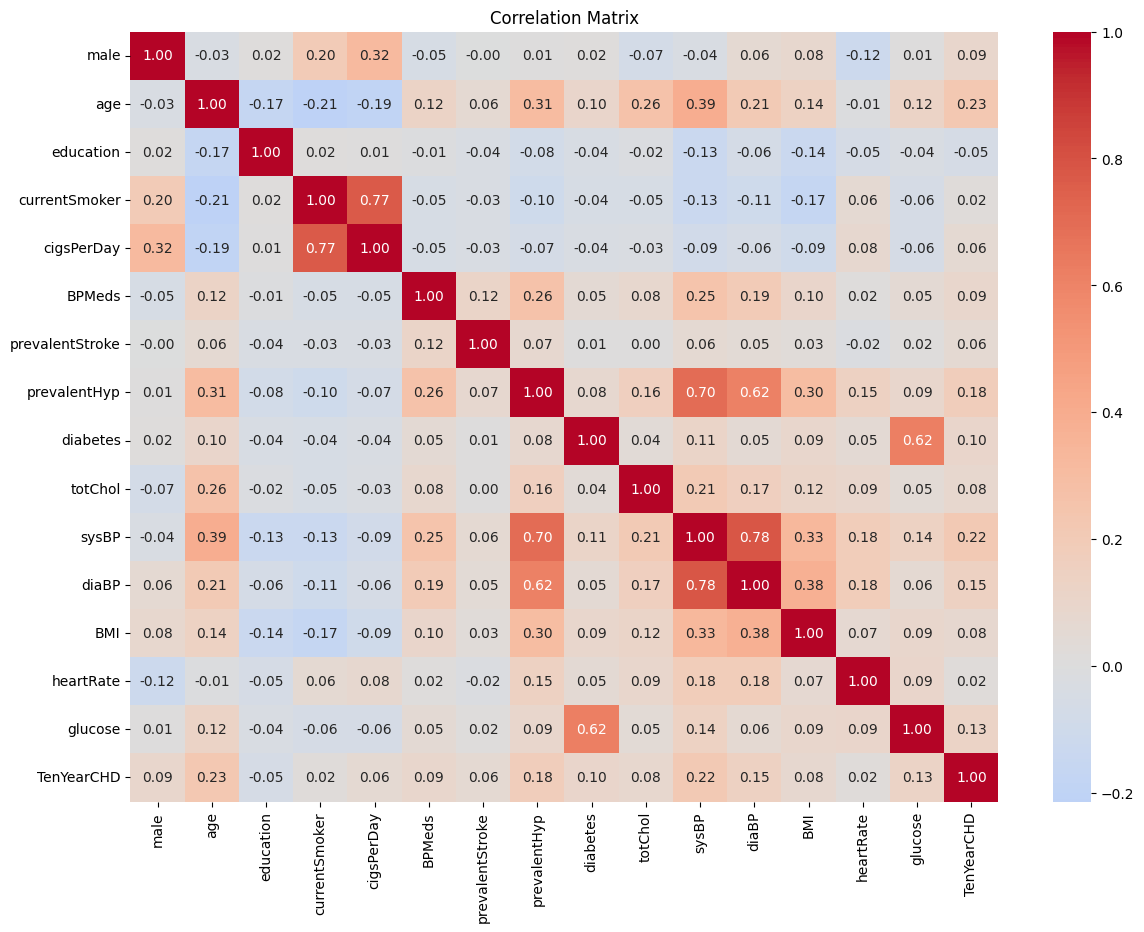

In [35]:
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

#Correlation with Target

In [36]:
target_correlation = (
    correlation_matrix["TenYearCHD"]
    .sort_values(ascending=False)
)

target_correlation

,TenYearCHD
TenYearCHD,1.000000
age,0.225256
sysBP,0.216429
prevalentHyp,0.177603
diaBP,0.145299
glucose,0.125544
diabetes,0.097317
male,0.088428
BPMeds,0.087489
totChol,0.082184


## Preparing the Dataset

For this first implementation, we will:

1. Remove the patient identifier.
2. Separate features from the target.
3. Handle missing values.
4. Split the data into training and testing sets.

We will avoid using the target variable as an input feature.

#Remove Patient ID

In [37]:
df_model = df.copy()

if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

df_model.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


#Handle Missing Values

In [38]:
for column in df_model.columns:
    if column != "TenYearCHD":
        df_model[column] = df_model[column].fillna(
            df_model[column].median()
        )

#Verify Missing Values

In [39]:
print(
    "Total missing values:",
    df_model.isnull().sum().sum()
)

Total missing values: 0


#Separate X and y

## Features and Target

X contains the patient information used by the model.

y contains the result we want to predict.

X → Patient Features

y → TenYearCHD

In [40]:
X = df_model.drop(
    columns=["TenYearCHD"]
)

y = df_model["TenYearCHD"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4238, 15)
y shape: (4238,)


#Inspect X and y

In [41]:
print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0



Target:


,TenYearCHD
0,0
1,0
2,0
3,1
4,0


#Final Dataset Check

In [42]:
print("=" * 50)
print("DATASET CHECK")
print("=" * 50)

print(f"Rows: {df_model.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Target classes: {sorted(y.unique())}")

print("\nClass distribution:")
print(y.value_counts())

print("=" * 50)

DATASET CHECK
Rows: 4238
Features: 15
Missing values: 0
Target classes: [np.int64(0), np.int64(1)]

Class distribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64


Kaggle Dataset
      ↓
Kaggle API
      ↓
Download Dataset
      ↓
Load with Pandas
      ↓
Inspect Data
      ↓
Handle Missing Values
      ↓
Separate X and y
      ↓
Ready for Logistic Regression

# Train/Test Split

We will divide the dataset into:

- 80% → Training data
- 20% → Testing data

The model learns from the training data and is evaluated on unseen testing data.

We use `stratify=y` so that the class distribution is approximately preserved
in both datasets.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3390
Testing samples: 848


#Check Class Distribution

In [44]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
TenYearCHD
0    0.848083
1    0.151917
Name: proportion, dtype: float64

Testing class distribution:
TenYearCHD
0    0.847877
1    0.152123
Name: proportion, dtype: float64


#Feature Scaling

# Feature Scaling

Logistic Regression can benefit from features being on comparable scales.

For example:

- Age may range from around 30–70
- Cholesterol may be in the hundreds
- Glucose may be around 50–400

StandardScaler transforms each feature approximately into:

Mean = 0

Standard Deviation = 1

We fit the scaler only on the training data and then use it to transform
both training and testing data.

#Create StandardScaler

In [45]:
scaler = StandardScaler()

#Fit and Transform Training Data

In [46]:
X_train_scaled = scaler.fit_transform(X_train)

print("Training data scaled successfully.")

Training data scaled successfully.


#Transform Testing Data

In [47]:
X_test_scaled = scaler.transform(X_test)

print("Testing data scaled successfully.")

Testing data scaled successfully.


In [48]:
scaler.fit_transform(X_train)

array([[-0.87237547,  0.16042193,  0.02064907, ..., -0.24406401,
        -0.49272528,  0.06054382],
       [-0.87237547,  1.09443712,  0.02064907, ...,  0.16146534,
         0.17311306,  0.2779168 ],
       [ 1.14629541,  0.86093332, -0.96527151, ...,  0.52571325,
        -1.07533383, -0.54810051],
       ...,
       [-0.87237547, -0.54008946,  1.99249024, ..., -0.35576671,
         0.17311306,  0.10401842],
       [-0.87237547, -1.24060085,  1.00656966, ..., -0.59617033,
        -0.99210403,  0.10401842],
       [-0.87237547, -0.54008946, -0.96527151, ...,  0.54513981,
        -0.15980611, -0.15682915]])

In [49]:
scaler.transform(X_test)

array([[ 1.14629541,  1.44469281, -0.96527151, ..., -1.12554397,
        -0.57595507, -0.54810051],
       [-0.87237547,  0.86093332, -0.96527151, ...,  3.00017077,
         0.7557216 , -0.28725294],
       [ 1.14629541, -0.07308187, -0.96527151, ...,  0.51114334,
        -0.07657632, -0.33072753],
       ...,
       [-0.87237547, -0.65684136,  1.00656966, ..., -1.64277601,
         0.7557216 ,  0.10401842],
       [-0.87237547, -1.00709705, -0.96527151, ..., -1.05026607,
        -1.3250232 , -0.06987996],
       [-0.87237547,  0.62742952, -0.96527151, ...,  0.15418038,
        -0.3262657 , -0.15682915]])

#Check Scaled Data

In [50]:
print("First 5 scaled training rows:")

display(
    pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns
    ).head()
)

First 5 scaled training rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,-0.872375,0.160422,0.020649,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,1.109723,0.187178,0.308956,-0.244064,-0.492725,0.060544
1,-0.872375,1.094437,0.020649,-0.982455,-0.751499,-0.172537,-0.080821,-0.671713,-0.165145,0.973192,-0.017371,0.435256,0.161465,0.173113,0.277917
2,1.146295,0.860933,-0.965272,1.017859,0.084843,-0.172537,-0.080821,1.488731,-0.165145,-0.687939,0.391726,0.014257,0.525713,-1.075334,-0.548101
3,1.146295,-1.707608,0.020649,1.017859,-0.500596,-0.172537,-0.080821,1.488731,-0.165145,1.041457,-0.971931,0.098457,0.875391,0.339573,-0.156829
4,-0.872375,-0.773593,-0.965272,1.017859,0.503014,-0.172537,-0.080821,-0.671713,-0.165145,1.792379,0.005357,-0.533042,1.390195,1.588020,-0.156829


#Verify Scaling

In [51]:
scaled_train_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("Mean:")
display(scaled_train_df.mean().round(2))

print("\nStandard Deviation:")
display(scaled_train_df.std().round(2))

Mean:


,0
male,-0.0
age,-0.0
education,-0.0
currentSmoker,-0.0
cigsPerDay,0.0
BPMeds,-0.0
prevalentStroke,-0.0
prevalentHyp,-0.0
diabetes,0.0
totChol,-0.0



Standard Deviation:


,0
male,1.0
age,1.0
education,1.0
currentSmoker,1.0
cigsPerDay,1.0
BPMeds,1.0
prevalentStroke,1.0
prevalentHyp,1.0
diabetes,1.0
totChol,1.0


#Create Logistic Regression Model

# Logistic Regression Model

Logistic Regression first calculates a linear combination of the features:

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

Then it applies the sigmoid function:

σ(z) = 1 / (1 + e⁻ᶻ)

The result is a probability between 0 and 1.

For binary classification:

Probability ≥ 0.5 → Class 1

Probability < 0.5 → Class 0

In [52]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


#Train the Model

In [53]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#Get Model Intercept

## Intercept

The intercept is represented by:

`b₀`

It is the starting point of the linear component of the Logistic Regression model.

In [54]:
print("Intercept:", logistic_model.intercept_[0])

Intercept: -2.000109592305966


## Feature Coefficients

Each feature receives a coefficient.

A positive coefficient means that increasing the feature increases the
linear model's log-odds of the positive class, while a negative coefficient
decreases them, holding the other included features constant.

Because we standardized the features, the coefficient magnitudes can be
compared more meaningfully than if the features were on very different scales.

In [55]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,age,0.571471
10,sysBP,0.322720
4,cigsPerDay,0.317173
0,male,0.225155
14,glucose,0.164493
9,totChol,0.099591
6,prevalentStroke,0.082471
7,prevalentHyp,0.078831
5,BPMeds,0.058336
8,diabetes,0.021294


#Visualize Coefficients

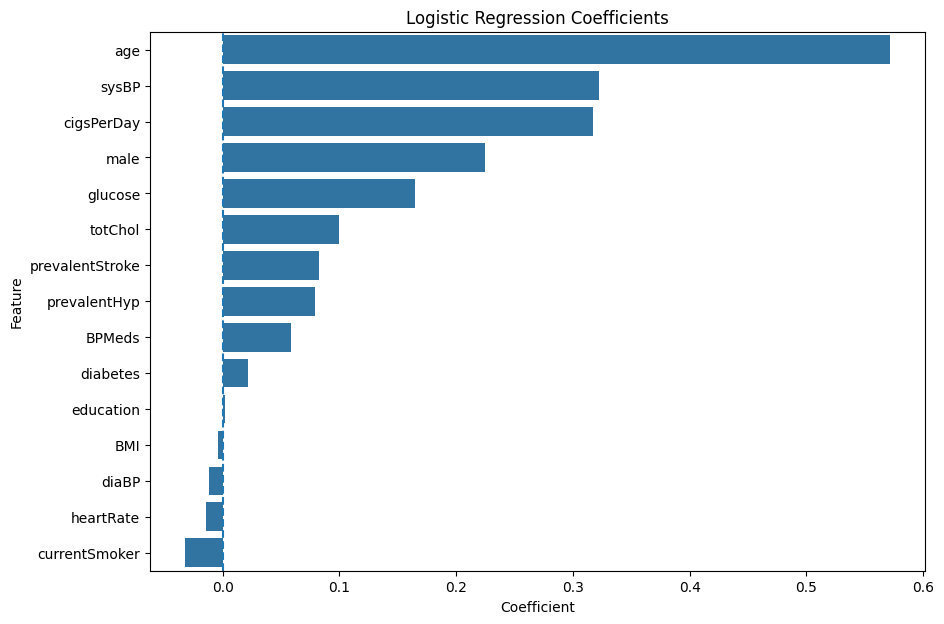

In [56]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

#Predict Classes

# Class Predictions

The `predict()` method converts the model's estimated probabilities into
class labels.

By default, binary Logistic Regression uses a probability threshold of
approximately 0.5.

Therefore:

Probability < 0.5 → Class 0

Probability ≥ 0.5 → Class 1

In [57]:
y_pred = logistic_model.predict(X_test_scaled)

print("Predicted classes:")
print(y_pred[:20])

Predicted classes:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


#Predict Probabilities

In [58]:
y_probability = logistic_model.predict_proba(
    X_test_scaled
)

print(y_probability[:10])

[[0.80438097 0.19561903]
 [0.78601585 0.21398415]
 [0.79846639 0.20153361]
 [0.47227318 0.52772682]
 [0.79177335 0.20822665]
 [0.8180305  0.1819695 ]
 [0.76928473 0.23071527]
 [0.9107921  0.0892079 ]
 [0.86266548 0.13733452]
 [0.83443452 0.16556548]]


#Extract Probability of Class 1

In [59]:
y_prob_class_1 = y_probability[:, 1]

print("Probability of Class 1:")
print(y_prob_class_1[:20])

Probability of Class 1:
[0.19561903 0.21398415 0.20153361 0.52772682 0.20822665 0.1819695
 0.23071527 0.0892079  0.13733452 0.16556548 0.05649382 0.13697656
 0.10662343 0.34206069 0.09163718 0.16691846 0.06089248 0.06485068
 0.11823073 0.32122403]


#Compare Probability and Prediction

In [60]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability_Class_1": y_prob_class_1,
    "Predicted_Class": y_pred
})

prediction_results.head(15)

,Actual,Probability_Class_1,Predicted_Class
0,0,0.195619,0
1,0,0.213984,0
2,1,0.201534,0
3,0,0.527727,1
4,0,0.208227,0
5,0,0.181969,0
6,0,0.230715,0
7,0,0.089208,0
8,0,0.137335,0
9,0,0.165565,0


#Understand the Threshold

In [61]:
prediction_results["Prediction_Using_0.5"] = (
    prediction_results["Probability_Class_1"] >= 0.5
).astype(int)

prediction_results.head(15)

,Actual,Probability_Class_1,Predicted_Class,Prediction_Using_0.5
0,0,0.195619,0,0
1,0,0.213984,0,0
2,1,0.201534,0,0
3,0,0.527727,1,1
4,0,0.208227,0,0
5,0,0.181969,0,0
6,0,0.230715,0,0
7,0,0.089208,0,0
8,0,0.137335,0,0
9,0,0.165565,0,0


#Verify Predictions

In [62]:
print(
    "Predictions match:",
    np.array_equal(
        y_pred,
        prediction_results["Prediction_Using_0.5"].values
    )
)

Predictions match: True


#Sort Predictions by Probability

In [63]:
prediction_results.sort_values(
    "Probability_Class_1",
    ascending=False
).head(20)

,Actual,Probability_Class_1,Predicted_Class,Prediction_Using_0.5
469,1,0.661239,1,1
685,1,0.650499,1,1
82,0,0.646643,1,1
225,1,0.645702,1,1
122,1,0.612839,1,1
605,0,0.609811,1,1
628,0,0.600242,1,1
170,0,0.595398,1,1
343,1,0.587813,1,1
784,1,0.571449,1,1


# Classification Threshold

The model produces probabilities.

We decide the final class using a threshold.

For example:

### Threshold = 0.50

Probability ≥ 0.50 → Class 1

### Threshold = 0.30

Probability ≥ 0.30 → Class 1

A lower threshold produces more positive predictions.

This can increase recall, but may also increase false positives.

For a medical-risk example, examining different thresholds can be useful
because missing a positive case can be more consequential than generating
an additional false positive.

In [64]:
threshold = 0.30

y_pred_030 = (
    y_prob_class_1 >= threshold
).astype(int)

print("Predictions using threshold 0.30:")
print(y_pred_030[:20])

Predictions using threshold 0.30:
[0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


#Compare 0.50 vs 0.30

In [65]:
threshold_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob_class_1,
    "Prediction_0.50": y_pred,
    "Prediction_0.30": y_pred_030
})

threshold_comparison.head(20)

,Actual,Probability,Prediction_0.50,Prediction_0.30
0,0,0.195619,0,0
1,0,0.213984,0,0
2,1,0.201534,0,0
3,0,0.527727,1,1
4,0,0.208227,0,0
5,0,0.181969,0,0
6,0,0.230715,0,0
7,0,0.089208,0,0
8,0,0.137335,0,0
9,0,0.165565,0,0


#Number of Positive Predictions

In [66]:
print(
    "Positive predictions at threshold 0.50:",
    y_pred.sum()
)

print(
    "Positive predictions at threshold 0.30:",
    y_pred_030.sum()
)

Positive predictions at threshold 0.50: 18
Positive predictions at threshold 0.30: 98


#Visualize Predicted Probabilities

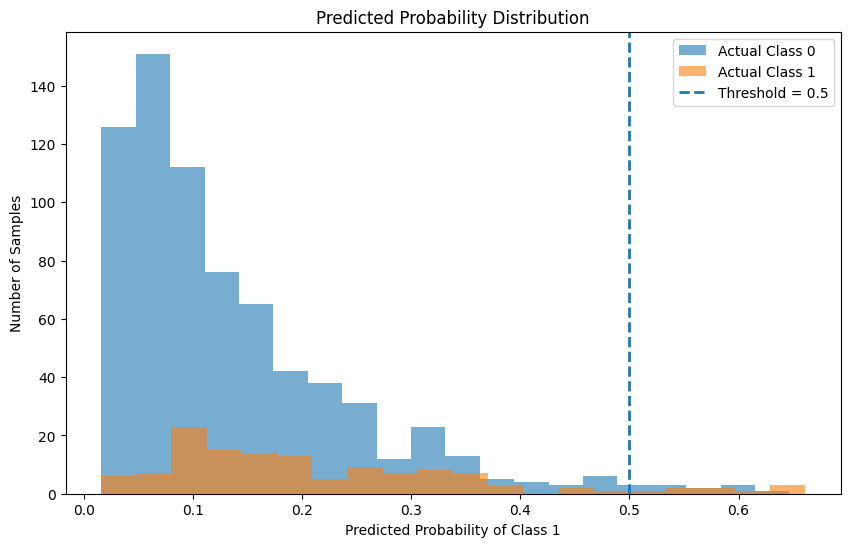

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(
    y_prob_class_1[y_test.values == 0],
    bins=20,
    alpha=0.6,
    label="Actual Class 0"
)

plt.hist(
    y_prob_class_1[y_test.values == 1],
    bins=20,
    alpha=0.6,
    label="Actual Class 1"
)

plt.axvline(
    x=0.5,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.5"
)

plt.xlabel("Predicted Probability of Class 1")
plt.ylabel("Number of Samples")
plt.title("Predicted Probability Distribution")

plt.legend()
plt.show()

#Create a Prediction Function

# Prediction Function

We can create a reusable function that takes patient features and returns:

- Predicted probability
- Predicted class

The input must contain the same features used during training.

In [68]:
def predict_heart_disease(input_data, threshold=0.5):

    input_df = pd.DataFrame(
        input_data,
        columns=X.columns
    )

    input_scaled = scaler.transform(input_df)

    probability = logistic_model.predict_proba(
        input_scaled
    )[:, 1][0]

    prediction = int(
        probability >= threshold
    )

    return probability, prediction

#Test the Prediction Function

In [69]:
sample_patient = X_test.iloc[[0]]

probability, prediction = predict_heart_disease(
    sample_patient.values
)

print("Predicted probability:", probability)
print("Predicted class:", prediction)

Predicted probability: 0.19561903485320933
Predicted class: 0


#Compare With Actual Value

In [70]:
actual_value = y_test.iloc[0]

print("Actual class:", actual_value)
print("Predicted class:", prediction)
print("Probability:", probability)

Actual class: 0
Predicted class: 0
Probability: 0.19561903485320933


#Test Multiple Patients

In [71]:
sample_patients = X_test.iloc[:10]

sample_probabilities = logistic_model.predict_proba(
    scaler.transform(sample_patients)
)[:, 1]

sample_predictions = (
    sample_probabilities >= 0.5
).astype(int)

test_examples = sample_patients.copy()

test_examples["Actual"] = y_test.iloc[:10].values
test_examples["Probability"] = sample_probabilities
test_examples["Prediction"] = sample_predictions

test_examples

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Actual,Probability,Prediction
1305,1,62,1.0,0,0.0,0.0,0,0,0,216.0,126.0,82.0,21.18,69.0,69.0,0,0.195619,0
4132,0,57,1.0,0,0.0,0.0,0,1,0,259.0,170.0,101.0,38.17,85.0,75.0,0,0.213984,0
2175,1,49,1.0,1,20.0,0.0,0,0,0,247.0,150.0,88.0,27.92,75.0,74.0,1,0.201534,0
3540,1,47,1.0,1,43.0,1.0,0,1,0,237.0,182.0,110.0,28.88,72.0,83.0,0,0.527727,1
2966,1,54,3.0,0,0.0,0.0,0,1,0,248.0,155.0,92.5,29.86,85.0,66.0,0,0.208227,0
1265,1,58,1.0,1,13.0,0.0,0,0,0,196.0,120.0,74.0,20.12,75.0,73.0,0,0.181969,0
2599,1,55,1.0,1,5.0,0.0,0,1,0,240.0,135.0,95.0,28.69,75.0,108.0,0,0.230715,0
1890,0,50,2.0,0,0.0,0.0,0,0,0,225.0,132.0,81.0,23.62,74.0,103.0,0,0.089208,0
1697,0,57,4.0,1,15.0,0.0,0,0,0,250.0,117.5,71.0,23.84,50.0,75.0,0,0.137335,0
1050,1,46,1.0,1,9.0,0.0,0,1,0,346.0,137.0,97.0,29.11,75.0,82.0,0,0.165565,0


#Model Training Summary

In [72]:
print("=" * 55)
print("LOGISTIC REGRESSION MODEL")
print("=" * 55)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nIntercept:")
print(logistic_model.intercept_[0])

print("\nNumber of coefficients:")
print(len(logistic_model.coef_[0]))

print("\nDefault threshold:")
print(0.5)

print("=" * 55)

LOGISTIC REGRESSION MODEL
Training samples: 3390
Testing samples: 848

Intercept:
-2.000109592305966

Number of coefficients:
15

Default threshold:
0.5


# Part 2 Complete

We have now:

- Split the data into training and testing sets
- Preserved class proportions using stratification
- Standardized the features
- Trained Logistic Regression
- Extracted the intercept
- Examined feature coefficients
- Generated class predictions
- Generated probability predictions
- Applied a 0.5 classification threshold
- Tested a different threshold
- Created a reusable prediction function
- Tested the model on unseen patient records

The important distinction is:

**Model → Probability → Threshold → Class**

For example:

**Probability = 0.73**

↓

**0.73 ≥ 0.50**

↓

**Predicted Class = 1**

Next we will evaluate the model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- ROC-AUC

and visualize how well the model performs.

#Model Evaluation & Visualization

#Accuracy

# Accuracy

Accuracy tells us the percentage of predictions that were correct.

Accuracy = Correct Predictions / Total Predictions

However, accuracy alone may not be sufficient when the classes are imbalanced.

In [73]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8479
Accuracy: 84.79%


#Precision

# Precision

Precision answers:

> Of all patients predicted as Class 1, how many were actually Class 1?

Precision = TP / (TP + FP)

High precision means fewer false-positive predictions.

In [74]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")

Precision: 0.5000


# Recall

Recall answers:

> Of all the actual Class 1 cases, how many did the model correctly identify?

Recall = TP / (TP + FN)

Recall is especially important to examine in medical-risk classification because false negatives can be consequential.

In [75]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Recall: {recall:.4f}")

Recall: 0.0698


# F1 Score

F1 Score combines Precision and Recall.

F1 = 2 × (Precision × Recall) / (Precision + Recall)

It is useful when we want a balance between precision and recall.

In [76]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.1224


#Classification Report

In [77]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       719
           1       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848



#Compare All Metrics

In [78]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics

,Metric,Score
0,Accuracy,0.847877
1,Precision,0.500000
2,Recall,0.069767
3,F1 Score,0.122449


#Visualize Model Metrics

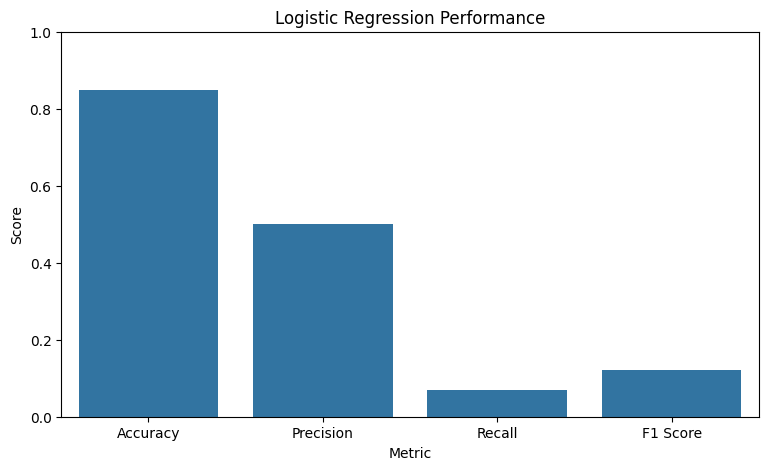

In [79]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Score"
)

plt.ylim(0, 1)
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

#Confusion Matrix

# Confusion Matrix

A confusion matrix shows how the model's predictions compare with the actual classes.

|                | Predicted 0 | Predicted 1 |
|----------------|-------------|-------------|
| Actual 0       | TN          | FP          |
| Actual 1       | FN          | TP          |

TN = True Negative

FP = False Positive

FN = False Negative

TP = True Positive

In [80]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[710   9]
 [120   9]]


#Visualize Confusion Matrix

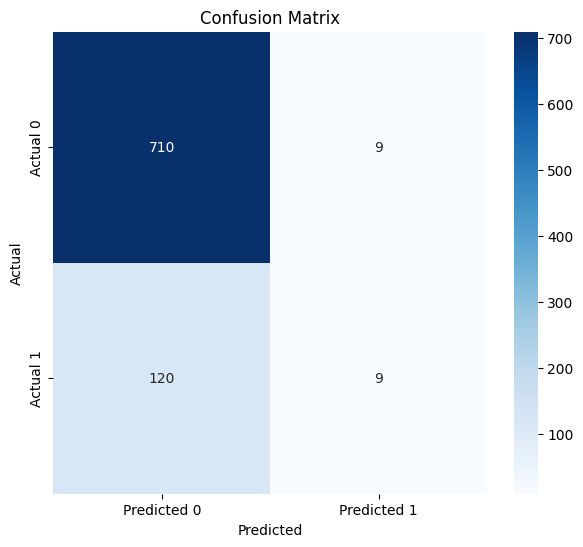

In [81]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Extract TP, TN, FP, FN

In [82]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 710
False Positive: 9
False Negative: 120
True Positive : 9


# ROC Curve

The ROC curve evaluates model performance across different classification thresholds.

It plots:

**True Positive Rate (Recall)**

against:

**False Positive Rate**

Different probability thresholds produce different classification results.

This helps us understand how the model behaves when the threshold changes.

In [83]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_class_1
)

#Plot ROC Curve

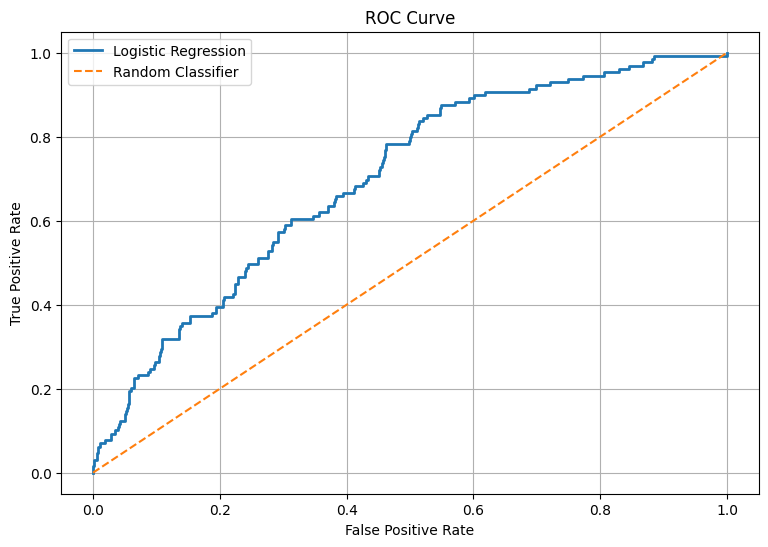

In [84]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

# ROC-AUC

AUC stands for:

**Area Under the ROC Curve**

AUC measures how well the model separates the two classes across thresholds.

A value closer to 1 generally indicates stronger ranking/separation performance.

A value around 0.5 indicates performance similar to random ranking.

In [85]:
auc_score = roc_auc_score(
    y_test,
    y_prob_class_1
)

print(f"ROC-AUC: {auc_score:.4f}")

ROC-AUC: 0.6995


#Add AUC to the ROC Plot

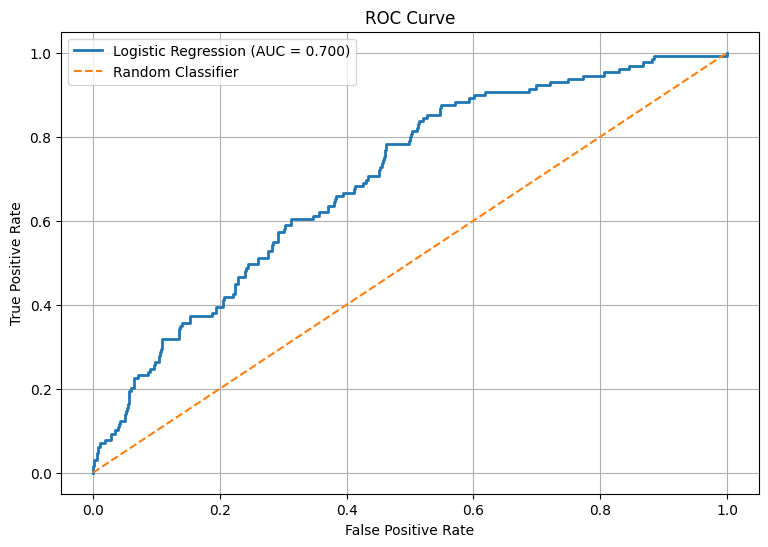

In [86]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

In this module, we built a complete Logistic Regression classification model
using a real-world heart disease dataset.

We covered the complete Machine Learning workflow:

1. Loaded a real-world dataset using the Kaggle API.
2. Explored and cleaned the dataset.
3. Handled missing values.
4. Performed basic Exploratory Data Analysis.
5. Separated features (`X`) and target (`y`).
6. Split the data into training and testing sets.
7. Standardized the features using `StandardScaler`.
8. Trained a Logistic Regression model.
9. Generated class probabilities using `predict_proba()`.
10. Converted probabilities into class predictions using a threshold.
11. Evaluated the model using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
    - ROC-AUC
12. Visualized model performance using:
    - Confusion Matrix
    - ROC Curve
    - Probability Distribution
    - Metric Comparison

## Key Concept

Logistic Regression follows:

Features
↓
Linear Combination

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

↓

Sigmoid Function

P(y=1) = 1 / (1 + e⁻ᶻ)

↓

Probability

↓

Classification Threshold

↓

Predicted Class

## What We Learned

Logistic Regression is useful when the target variable represents
different classes, especially binary outcomes such as:

- 0 / 1
- Yes / No
- Pass / Fail
- Spam / Not Spam
- Churn / No Churn

The most important difference from Linear Regression is that Logistic
Regression produces a **probability**, which can then be converted into
a class prediction.

## Important Takeaway

A Machine Learning model should not be judged using only one metric.

For classification problems, we should examine:

**Accuracy + Precision + Recall + F1 Score + Confusion Matrix + ROC-AUC**

and select the classification threshold according to the requirements of
the problem.

## Final Workflow

**Real-World Data**

→ **Data Preparation**

→ **Train/Test Split**

→ **Feature Scaling**

→ **Model Training**

→ **Probability Prediction**

→ **Class Prediction**

→ **Model Evaluation**

→ **Visualization**

→ **Interpretation**

This completes the Logistic Regression module.

> The heart disease dataset and model used in this notebook are for
> Machine Learning education only and should not be used for medical
> diagnosis or clinical decision-making.